In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [3]:
# fetch dataset 
concrete_compressive_strength = fetch_ucirepo(id=165) 
  
# data (as pandas dataframes) 
X = concrete_compressive_strength.data.features 
y = concrete_compressive_strength.data.targets.squeeze()

# from instructions, use samples 501-630 as testing set, remaining 900 as training set
X_train = X.drop(X.index[501:631])
X_test = X[501:631]
y_train = y.drop(y.index[501:631])
y_test = y[501:631]

# standardized datasets
X_train_mean = X_train.mean(axis=0)
X_train_var = X_train.std(axis=0)
X_train_st = (X_train - X_train_mean) / X_train_var
X_test_st = (X_test - X_train_mean) / X_train_var

# we want to eventually have model: Concrete_Strength = m1 * Cement + m2 * Blast_Furnace_Slag + … + m8 * Age + b
# print(X.columns)
model = LinearRegression()


In [4]:
# function to perform gradient optimization using MSE as loss function
def grad_descent(X, y, w_init, learn_rate, threshold, max_steps = 10000): 
    # include max_steps as a hyperparam in case we get stuck in a vanishing grad or exploding grad problem
    n = X.shape[0]
    # add a column of ones to the beginning of X to allow matrix mult with w_init = [b, m1, m2, ..., ]
    X_with_bias = np.hstack([np.ones((X.shape[0], 1)), X])

    w = w_init.copy() # initialize parameters (weights)
    for i in range(max_steps):
        grad = (1/n) * 2*(X_with_bias.T @ (X_with_bias @ w - y)) # X_with_bias @ y = predictions
        if (np.all(np.abs(grad)< threshold)): # magnitudes of grad < threshold --> no more meaningful improvement, stop
            break
        w -= learn_rate*grad # update parameters
    return w

In [5]:
# it turns out that I only needed to do one step rip
def onestep_graddesc(X, y, w_init, learn_rate):
    n = X.shape[0]
    # add a column of ones to the beginning of X to allow matrix mult with w_init = [b, m1, m2, ..., ]
    X_with_bias = np.hstack([np.ones((X.shape[0], 1)), X])

    w = w_init.copy() # initialize parameters (weights)
    grad = (1/n) * 2*(X_with_bias.T @ (X_with_bias @ w - y)) # X_with_bias @ y = predictions
    w -= learn_rate*grad # update parameters
    return w

In [6]:
# Univariate Models set 1
learn_rate = 0.001
threshold = 1e-6
max_steps = 10000

for feature_to_use in X_train_st.columns:

    print(feature_to_use)

    # Numpy arrs, using standardized vals
    X_feature_train = X_train_st[[feature_to_use]].values
    X_feature_test = X_test_st[[feature_to_use]].values
    #y_vals_train = y_train.values
    y_vals = y_train.to_numpy().reshape(-1)

    w_init = np.zeros(2)
    w = grad_descent(X_feature_train, y_vals, w_init, learn_rate, threshold)

    # Add bias column of ones for matrix mult with weights
    X_feature_train_with_bias = np.hstack([np.ones((X_feature_train.shape[0], 1)),X_feature_train])

    X_feature_test_with_bias = np.hstack([
        np.ones((X_feature_test.shape[0], 1)),
        X_feature_test
    ])

    # Predictions
    y_pred_train = X_feature_train_with_bias @ w
    y_pred_test = X_feature_test_with_bias @ w

    # Results
    mse_train = mean_squared_error(y_train, y_pred_train)
    r_squared_train = r2_score(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    r_squared_test = r2_score(y_test, y_pred_test)

    print(f"Model: Strength = {w[0]} + {w[1]}*{feature_to_use}")
    print(f"MSE on Training: {mse_train}")
    print(f"R squared on Training: {r_squared_train}")
    print(f"MSE on Test: {mse_test}")
    print(f"R squared on Test: {r_squared_test}\n")

Cement
Model: Strength = 36.97199950065336 + 8.58107132447771*Cement
MSE on Training: 203.52735421370562
R squared on Training: 0.2654572124696276
MSE on Test: 268.10329480126063
R squared on Test: -0.23130467057361037

Blast Furnace Slag
Model: Strength = 36.97199950065337 + 2.623708203159766*Blast Furnace Slag
MSE on Training: 270.2041286804117
R squared on Training: 0.024816616666068048
MSE on Test: 309.0863272633316
R squared on Test: -0.4195254058772355

Fly Ash
Model: Strength = 36.97199950065337 + -3.4270327526971007*Fly Ash
MSE on Training: 265.34882058136157
R squared on Training: 0.04233972337166736
MSE on Test: 382.7892902414545
R squared on Test: -0.7580173390604823

Water
Model: Strength = 36.97199950065337 + -4.588719341594904*Water
MSE on Training: 256.04737505235687
R squared on Training: 0.07590921457511046
MSE on Test: 260.30583381854325
R squared on Test: -0.19549365924772388

Superplasticizer
Model: Strength = 36.97199950065336 + 5.279438952023156*Superplasticizer
M

In [7]:
# Univariate Models set 2
learn_rates = [1e-6, 1e-10, 5e-5, 1e-5, 1e-4, 1e-6, 1e-6, 1e-6]
threshold = 1e-12
max_steps = 10**6

for i in range(X_train.shape[1]):   # number of features

    feature_to_use = X_train.columns[i]
    print(feature_to_use)

    # panda to numpy arrs, don't use standardized vals
    X_feature_train = X_train[[feature_to_use]].values
    X_feature_test = X_test[[feature_to_use]].values
    y_vals = y_train.to_numpy().reshape(-1)

    w_init = np.zeros(2)

    # w = onestep_graddesc(X_feature_train,y_vals, w_init, learn_rates[i], threshold, max_steps)
    w = grad_descent(X_feature_train,y_vals, w_init, learn_rates[i], threshold, max_steps)

    # Add bias column of ones for matrix mult with weights
    X_feature_train_with_bias = np.hstack([np.ones((X_feature_train.shape[0], 1)), X_feature_train])

    X_feature_test_with_bias = np.hstack([np.ones((X_feature_test.shape[0], 1)), X_feature_test])

    # Predictions
    y_pred_train = X_feature_train_with_bias @ w
    y_pred_test = X_feature_test_with_bias @ w

    # Results
    mse_train = mean_squared_error(y_train, y_pred_train)
    r_squared_train = r2_score(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    r_squared_test = r2_score(y_test, y_pred_test)

    print(f"Model: Strength = {w[0]} + {w[1]}*{feature_to_use}")
    print(f"Learn rate used = {learn_rates[i]}")
    print(f"w = {w[1]}")
    print(f"b = {w[0]}")
    print(f"MSE Train: {mse_train}")
    print(f"R squared Train: {r_squared_train}")
    print(f"MSE Test: {mse_test}")
    print(f"R squared Test: {r_squared_test}\n")

Cement
Model: Strength = 3.25615800944087 + 0.11606850873279254*Cement
Learn rate used = 1e-06
w = 0.11606850873279254
b = 3.25615800944087
MSE Train: 219.6037261025238
R squared Train: 0.20743659373654044
MSE Test: 256.36397224452554
R squared Test: -0.1773900676061495

Blast Furnace Slag
Model: Strength = 0.005089937629228833 + 0.21805373646789544*Blast Furnace Slag
Learn rate used = 1e-10
w = 0.21805373646789544
b = 0.005089937629228833
MSE Train: 931.2774388006976
R squared Train: -2.3610377755047978
MSE Test: 967.2773069882239
R squared Test: -3.44236638985484

Fly Ash
Model: Strength = 40.03890169223313 + -0.05332299519051452*Fly Ash
Learn rate used = 5e-05
w = -0.05332299519051452
b = 40.03890169223313
MSE Train: 265.34882058136134
R squared Train: 0.04233972337166836
MSE Test: 382.78930205214544
R squared Test: -0.7580173933028551

Water
Model: Strength = 19.18469033850259 + 0.09386118294893957*Water
Learn rate used = 1e-05
w = 0.09386118294893957
b = 19.18469033850259
MSE Trai

In [8]:
# Multivariate Model set 1
learn_rate = 0.1
threshold = 1e-6

w_init = np.zeros(X_train_st.shape[1] + 1)
y_vals = y_train.to_numpy().reshape(-1)

w = grad_descent(X_train_st.values, y_vals, w_init, learn_rate, threshold)

# Training
X_train_st_with_bias = np.hstack([np.ones((X_train_st.shape[0], 1)), X_train_st.values])
y_pred_train = X_train_st_with_bias @ w

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

X_test_st_with_bias = np.hstack([np.ones((X_test_st.shape[0], 1)), X_test_st.values])
y_pred_test = X_test_st_with_bias @ w

mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("Weights:")
print(w)
print(f"Train MSE: {mse_train}")
print(f"Train R^2: {r2_train}")
print(f"Test MSE: {mse_test}")
print(f"Test R^2: {r2_test}")

Weights:
[36.972      14.11120268 10.51005333  6.86004963 -2.96716824  0.69460401
  2.22171174  2.79211359  7.28240726]
Train MSE: 104.15446393496804
Train R^2: 0.624100108960336
Test MSE: 141.2579420009313
Test R^2: 0.3512516738360313


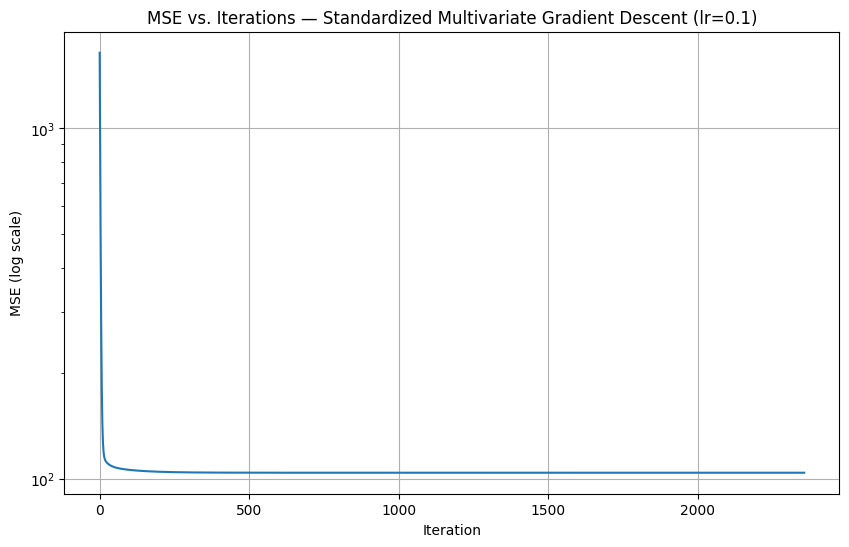

Converged after 2357 iterations
Final MSE: 104.1545


In [11]:
# GD with MSE tracking for the standardized multivariate model
def grad_descent_track_mse(X, y, w_init, learn_rate, threshold, max_steps=10000):
    n = X.shape[0]
    X_with_bias = np.hstack([np.ones((X.shape[0], 1)), X])
    w = w_init.copy()
    mse_history = []
    for i in range(max_steps):
        predictions = X_with_bias @ w
        mse = np.mean((predictions - y) ** 2)
        mse_history.append(mse)
        grad = (1/n) * 2 * (X_with_bias.T @ (predictions - y))
        if np.all(np.abs(grad) < threshold):
            break
        w -= learn_rate * grad
    return w, mse_history

# Rerun standardized multivariate model with MSE tracking
# Re-fetch data with fresh X_train/y_train
concrete_compressive_strength = fetch_ucirepo(id=165)
X = concrete_compressive_strength.data.features
y = concrete_compressive_strength.data.targets.squeeze()
X_train = X.drop(X.index[501:631])
y_train = y.drop(y.index[501:631])
X_train_mean = X_train.mean(axis=0)
X_train_var = X_train.std(axis=0)
X_train_st = (X_train - X_train_mean) / X_train_var

w_init = np.zeros(X_train_st.shape[1] + 1)
y_vals = y_train.to_numpy().reshape(-1)
w, mse_history = grad_descent_track_mse(X_train_st.values, y_vals, w_init, 0.1, 1e-6)

plt.figure(figsize=(10, 6))
plt.plot(range(len(mse_history)), mse_history)
plt.xlabel('Iteration')
plt.ylabel('MSE (log scale)')
plt.yscale('log')
plt.title('MSE vs. Iterations: Standardized Multivariate Gradient Descent (learn=0.1)')
plt.grid(True)
plt.show()

print(f"Converged after {len(mse_history)} iterations")
print(f"Final MSE: {mse_history[-1]:.4f}")

In [10]:
# Multivariate Model set 2
learn_rate = 5e-7
threshold = 1e-6

w_init = np.zeros(X_train.shape[1] + 1)
y_vals = y_train.to_numpy().reshape(-1)

w = grad_descent(X_train.values, y_vals, w_init, learn_rate, threshold)

# Training
X_train_with_bias = np.hstack([np.ones((X_train.shape[0], 1)), X_train.values])
y_pred_train = X_train_with_bias @ w

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

X_test_with_bias = np.hstack([np.ones((X_test.shape[0], 1)), X_test.values])
y_pred_test = X_test_with_bias @ w

mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("Weights:")
print(w)
print(f"Train MSE: {mse_train}")
print(f"Train R^2: {r2_train}")
print(f"Test MSE: {mse_test}")
print(f"Test R^2: {r2_test}")

Weights:
[-1.98280430e-04  1.18800097e-01  1.07844602e-01  8.77549756e-02
 -2.05979628e-01  3.75649955e-02  1.08759336e-02  1.50326684e-02
  1.18385070e-01]
Train MSE: 104.54126267994796
Train R^2: 0.6227041284079996
Test MSE: 139.2720195772625
Test R^2: 0.3603723210010462


In [11]:
# Q2 Multivariate Linear Models
X_train = np.array([[3,4,5]])
y_train = np.array([4])

w_init = np.ones(X_train.shape[1] + 1)
learn_rate = 0.1
threshold = 0.001
max_steps = 100

w = onestep_graddesc(X_train, y_train, w_init, learn_rate)
print(w)

[-0.8 -4.4 -6.2 -8. ]


In [12]:
# Q2 Multivariate Linear Models

X_train = np.array([
    [3, 4, 4],
    [4, 2, 1],
    [10, 2, 5],
    [3, 4, 5],
    [11, 1, 1]
])

y_train = np.array([3, 2, 8, 4, 5])

w_init = np.ones(4)
learn_rate = 0.1

w = onestep_graddesc(X_train, y_train, w_init, learn_rate)

print(w)


[ -0.72 -10.08  -3.52  -4.84]
